In [ ]:
!pip install transformers torch

from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
from google.colab import files
uploaded = files.upload()  # carica df_sunscreen_augmented.csv


Saving df_sunscreen_augmented.csv to df_sunscreen_augmented.csv


In [ ]:
import pandas as pd
df = pd.read_csv('df_sunscreen_augmented.csv')
print(f"Shape: {df.shape}")

Shape: (287, 12)


In [ ]:
# RoBERTa expects max 512 tokens - truncate long texts
def get_roberta_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_pipeline(text[:512], truncation=True)[0]
    return result['label'], result['score']

print("Running RoBERTa...")
df[['roberta_label', 'roberta_score']] = df['Text'].apply(
    lambda x: pd.Series(get_roberta_sentiment(x))
)

print("Done!")
print(df['roberta_label'].value_counts())

Running RoBERTa...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done!
roberta_label
negative    118
neutral     107
positive     62
Name: count, dtype: int64


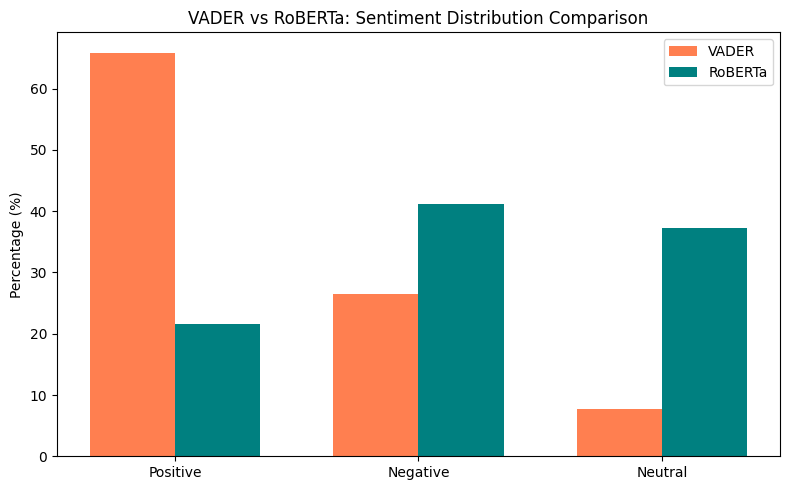

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Positive', 'Negative', 'Neutral']
vader = [65.9, 26.5, 7.7]
roberta = [21.6, 41.1, 37.3]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, vader, width, label='VADER', color='coral')
ax.bar(x + width/2, roberta, width, label='RoBERTa', color='teal')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage (%)')
ax.set_title('VADER vs RoBERTa: Sentiment Distribution Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('vader_vs_roberta.png', dpi=150)
plt.show()

In [ ]:
# map RoBERTa labels to numeric scores for comparison
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['roberta_score_numeric'] = df['roberta_label'].map(label_map)

brands_of_interest = [
    'Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
    'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum'
]

brand_roberta = {}
for brand in brands_of_interest:
    mask = df['Text'].str.contains(brand, case=False, na=False)
    docs = df[mask]
    if len(docs) > 0:
        brand_roberta[brand] = docs['roberta_score_numeric'].mean()

import pandas as pd
brand_roberta_df = pd.Series(brand_roberta).sort_values()
print(brand_roberta_df)

Coppertone        -0.600000
Hawaiian Tropic   -0.541667
Banana Boat       -0.459459
Neutrogena        -0.076923
Raw Elements      -0.041667
Stream2Sea         0.115385
Sun Bum            0.250000
Thinksport         0.290323
Badger Balm        0.470588
dtype: float64


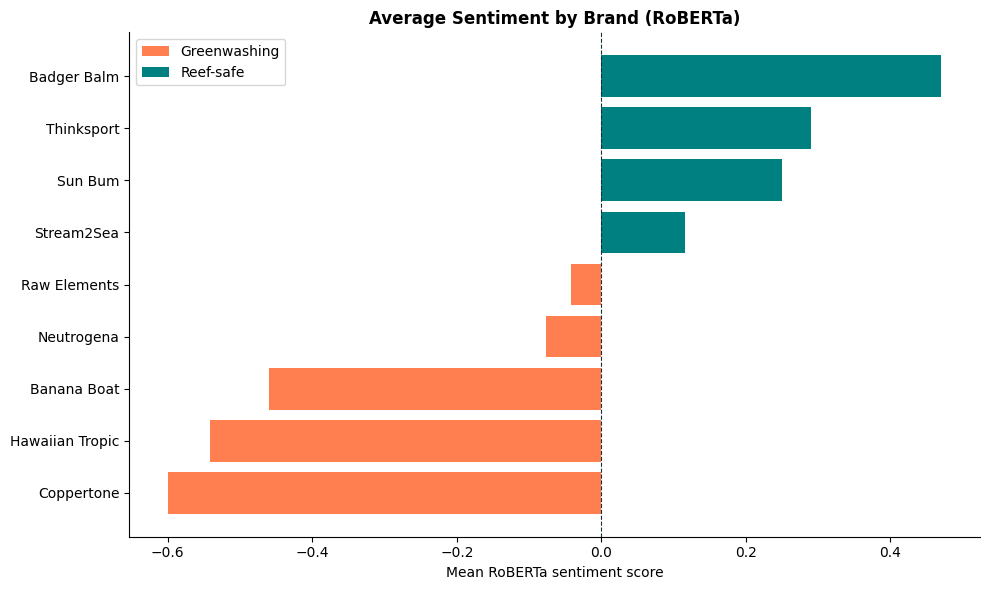

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = ['coral' if v < 0 else 'teal' for v in brand_roberta_df.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(brand_roberta_df.index, brand_roberta_df.values, color=colors)
ax.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean RoBERTa sentiment score')
ax.set_title('Average Sentiment by Brand (RoBERTa)', fontweight='bold')
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
ax.legend(handles=legend_elements)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('brand_sentiment_roberta.png', dpi=150)
plt.show()

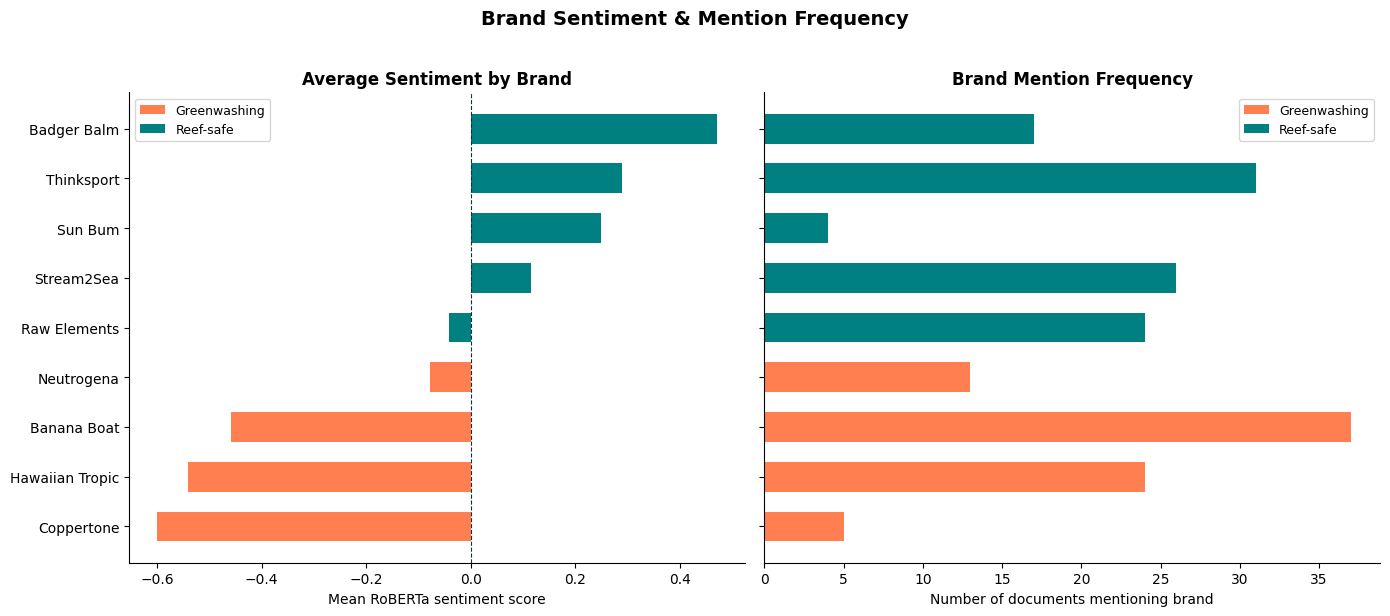

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import pandas as pd

brands = ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
          'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

categories = {
    'Banana Boat': 'Greenwashing', 'Hawaiian Tropic': 'Greenwashing',
    'Neutrogena': 'Greenwashing', 'Coppertone': 'Greenwashing',
    'Stream2Sea': 'Reef-safe', 'Raw Elements': 'Reef-safe',
    'Thinksport': 'Reef-safe', 'Badger Balm': 'Reef-safe', 'Sun Bum': 'Reef-safe'
}

# RoBERTa scores (già calcolati)
roberta_scores = {
    'Coppertone': -0.600000,
    'Hawaiian Tropic': -0.541667,
    'Banana Boat': -0.459459,
    'Neutrogena': -0.076923,
    'Raw Elements': -0.041667,
    'Stream2Sea': 0.115385,
    'Sun Bum': 0.250000,
    'Thinksport': 0.290323,
    'Badger Balm': 0.470588
}

# Mention counts
mention_counts = {}
for brand in brands:
    mask = df['Text'].str.contains(brand, case=False, na=False)
    mention_counts[brand] = mask.sum()

# Ordina per sentiment RoBERTa crescente (stesso ordine in entrambi)
sorted_brands = sorted(brands, key=lambda b: roberta_scores.get(b, 0))
sorted_scores = [roberta_scores.get(b, 0) for b in sorted_brands]
sorted_counts = [mention_counts.get(b, 0) for b in sorted_brands]
colors = ['coral' if categories[b] == 'Greenwashing' else 'teal' for b in sorted_brands]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]

# LEFT: sentiment
ax1.barh(sorted_brands, sorted_scores, color=colors, height=0.6)
ax1.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean RoBERTa sentiment score')
ax1.set_title('Average Sentiment by Brand', fontweight='bold')
ax1.legend(handles=legend_elements, fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# RIGHT: mention frequency (stesso ordine)
ax2.barh(sorted_brands, sorted_counts, color=colors, height=0.6)
ax2.set_xlabel('Number of documents mentioning brand')
ax2.set_title('Brand Mention Frequency', fontweight='bold')
ax2.set_yticklabels([])  # nasconde le label duplicate
ax2.legend(handles=legend_elements, fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Brand Sentiment & Mention Frequency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('brand_sentiment_roberta_combined.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
accc_keywords = ['ACCC', 'Edgewell', 'Federal Court']
mask_accc = df['Text'].str.contains('|'.join(accc_keywords), case=False, na=False)
df_accc = df[mask_accc].copy()
print(f"ACCC docs: {len(df_accc)}")
print(df_accc['roberta_label'].value_counts())

ACCC docs: 75
roberta_label
neutral     36
negative    31
positive     8
Name: count, dtype: int64


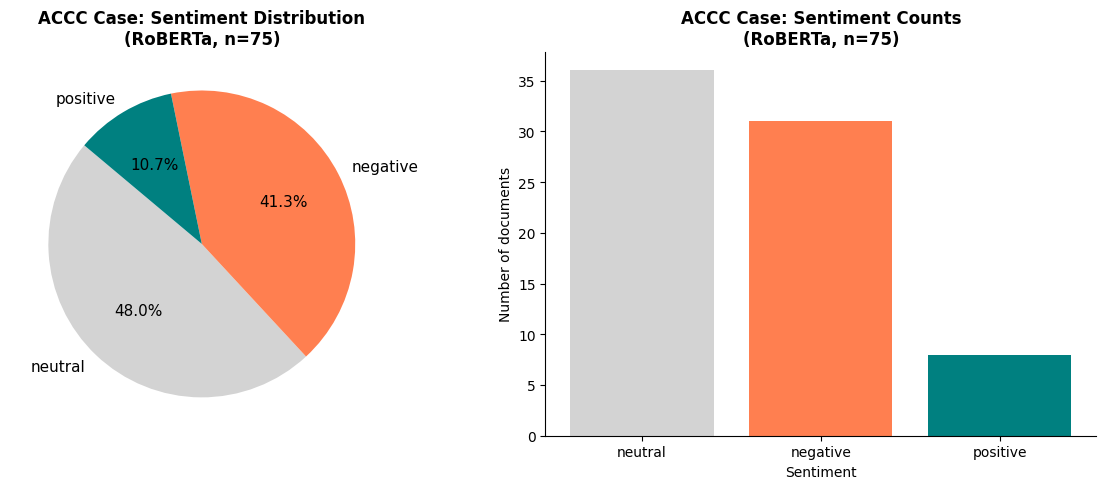

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
sentiment_counts = df_accc['roberta_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax1.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        textprops={'fontsize': 11})
ax1.set_title('ACCC Case: Sentiment Distribution\n(RoBERTa, n=75)', fontweight='bold')

# Bar chart
ax2.bar(sentiment_counts.index, sentiment_counts.values,
        color=[pie_colors[s] for s in sentiment_counts.index])
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Number of documents')
ax2.set_title('ACCC Case: Sentiment Counts\n(RoBERTa, n=75)', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('accc_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

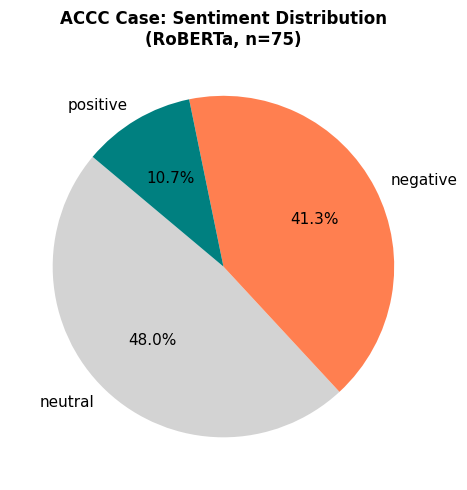

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sentiment_counts = df_accc['roberta_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax.pie(sentiment_counts.values,
       labels=sentiment_counts.index,
       autopct='%1.1f%%',
       colors=colors_pie,
       startangle=140,
       textprops={'fontsize': 11})
ax.set_title('ACCC Case: Sentiment Distribution\n(RoBERTa, n=75)', fontweight='bold')

plt.tight_layout()
plt.savefig('accc_roberta_pie.png', dpi=150, bbox_inches='tight')
plt.show()